In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

train_df = pd.read_csv(
    "CMAPSSData/train_FD001.txt", sep=r"\s+", header=None, names=columns
)


test_df = pd.read_csv(
    "CMAPSSData/test_FD001.txt", sep=r"\s+", header=None, names=columns
)

rul_test_df = pd.read_csv(
    "CMAPSSData/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
)

In [3]:
print(train_df.columns.tolist())
print(train_df.shape)
print(train_df.head())
print(test_df.shape)
print(rul_test_df.shape)

['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
(20631, 26)
   unit_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0        1      1       -0.0007       -0.0004         100.0    518.67   
1        1      2        0.0019       -0.0003         100.0    518.67   
2        1      3       -0.0043        0.0003         100.0    518.67   
3        1      4        0.0007        0.0000         100.0    518.67   
4        1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   


In [4]:
max_cycle = train_df.groupby("unit_id")["cycle"].max()
train_df["Remaining Useful Life"] = (
    train_df["unit_id"].map(max_cycle) - train_df["cycle"]
)

Описание датасета

In [5]:
from IPython.display import display

print("Train dataset overview")
print(f"Rows: {train_df.shape[0]}, columns: {train_df.shape[1]}")
print(f"Units: {train_df['unit_id'].nunique()}")
print(f"Cycle range: {train_df['cycle'].min()} - {train_df['cycle'].max()}")
print(f"Missing values: {train_df.isna().sum().sum()}")

display(train_df.describe().T)

sensor_summary = train_df.filter(like="sensor_").agg(["mean", "std", "min", "max"]).T
display(sensor_summary)

Train dataset overview
Rows: 20631, columns: 27
Units: 100
Cycle range: 1 - 362
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
unit_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


,mean,std,min,max
sensor_1,518.670000,0.000000e+00,518.6700,518.6700
sensor_2,642.680934,5.000533e-01,641.2100,644.5300
sensor_3,1590.523119,6.131150e+00,1571.0400,1616.9100
sensor_4,1408.933782,9.000605e+00,1382.2500,1441.4900
sensor_5,14.620000,1.776400e-15,14.6200,14.6200
sensor_6,21.609803,1.388985e-03,21.6000,21.6100
sensor_7,553.367711,8.850923e-01,549.8500,556.0600
sensor_8,2388.096652,7.098548e-02,2387.9000,2388.5600
sensor_9,9065.242941,2.208288e+01,9021.7300,9244.5900
sensor_10,1.300000,0.000000e+00,1.3000,1.3000


 тестики

In [17]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
target_col = "Remaining Useful Life"

feature_cols = [
    col
    for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

test_last_rows = (
    test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_last_rows[feature_cols]
y_test = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test) != len(y_test):
    raise ValueError("test feature rows must match RUL target rows")

rf_params = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 3,
    "min_samples_split": 5,
    "random_state": 42,
    "n_jobs": -1,
}


print(f"Train units: {train_df['unit_id'].nunique()}, rows: {len(X_train)}")
print(f"Test units: {test_last_rows['unit_id'].nunique()}, rows: {len(X_test)}")

Train units: 100, rows: 20631
Test units: 100, rows: 100


In [34]:
rf_model = RandomForestRegressor(**rf_params)
rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [35]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae, rmse, r2],
    }
)

metrics_df

,metric,value
0,MAE,24.113318
1,RMSE,32.807849
2,R2,0.376702


In [21]:
print(train_df["Remaining Useful Life"].describe())


import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_rul = y_train.mean()
y_pred_dummy = np.full(len(y_test), mean_rul)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = mean_squared_error(y_test, y_pred_dummy) ** 0.5

print("Dummy MAE =", mae_dummy)
print("Dummy RMSE =", rmse_dummy)
# Понять насколько ошибка 24 это много

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: Remaining Useful Life, dtype: float64
Dummy MAE = 40.87930202123019
Dummy RMSE = 52.62485752612688


На данный момент была проблема что он смотрел только на последнюю но ведь мы смотрим в целом на картину по последним изменениям поэтому добавим окно

In [37]:
window_size = 20


def build_lag_window_features(
    source_df, include_target=False, require_full_window=False
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    first_values = sorted_df.groupby("unit_id")[feature_cols].transform("first")
    lagged_parts = []

    for lag in range(window_size):
        shifted = sorted_df.groupby("unit_id")[feature_cols].shift(lag)
        if not require_full_window:
            shifted = shifted.fillna(first_values)
        suffix = "t" if lag == 0 else f"t_minus_{lag}"
        shifted.columns = [f"{col}_{suffix}" for col in feature_cols]
        lagged_parts.append(shifted)

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    result_df = pd.concat(
        [sorted_df[metadata_cols], *lagged_parts],
        axis=1,
    )

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= window_size].dropna()

    return result_df.reset_index(drop=True)


window_train_df = build_lag_window_features(
    train_df,
    include_target=True,
    require_full_window=True,
)
window_test_df = build_lag_window_features(
    test_df,
    include_target=False,
    require_full_window=False,
)

window_feature_cols = [
    col
    for col in window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]

window_test_last_rows = (
    window_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_window = window_train_df[window_feature_cols]
y_train_window = window_train_df[target_col]

X_test_window = window_test_last_rows[window_feature_cols]
y_test_window = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test_window) != len(y_test_window):
    raise ValueError("test feature rows must match RUL target rows")

window_rf_params = rf_params.copy()

print(f"Window size: {window_size}")
print(
    "Train mode: require full window; test mode: use available history and keep every test unit"
)
print(f"Train rows: {len(X_train_window)}, features: {X_train_window.shape[1]}")
print(f"Test rows: {len(X_test_window)}, features: {X_test_window.shape[1]}")

Window size: 20
Train mode: require full window; test mode: use available history and keep every test unit
Train rows: 18731, features: 480
Test rows: 100, features: 480


In [11]:
window_rf_model = RandomForestRegressor(**window_rf_params)
window_rf_model.fit(X_train_window, y_train_window)

print("Window Random Forest model trained")

Window Random Forest model trained


In [12]:
y_pred_window = window_rf_model.predict(X_test_window)

mae_window = mean_absolute_error(y_test_window, y_pred_window)
rmse_window = mean_squared_error(y_test_window, y_pred_window) ** 0.5
r2_window = r2_score(y_test_window, y_pred_window)

window_metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae_window, rmse_window, r2_window],
    }
)

window_metrics_df

,metric,value
0,MAE,15.016407
1,RMSE,20.499835
2,R2,0.756644


На данных в большом количестве тяжело учить плюс это перегружает дерево поэтому вместо этого делаем сбалансированные признаки

In [22]:
agg_window_size = 50

if agg_window_size < 2:
    raise ValueError("agg_window_size must be at least 2")


def calculate_slope(values):
    x = np.arange(len(values))
    x = x - x.mean()
    denominator = (x**2).sum()
    if denominator == 0:
        return 0
    return np.dot(values, x) / denominator


def build_agg_window_features(
    source_df, include_target=False, require_full_window=False
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    min_periods = agg_window_size if require_full_window else 1
    rolling_features = sorted_df.groupby("unit_id")[feature_cols].rolling(
        window=agg_window_size,
        min_periods=min_periods,
    )

    mean_features = rolling_features.mean().reset_index(level=0, drop=True)
    std_features = (
        rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    )
    min_features = rolling_features.min().reset_index(level=0, drop=True)
    max_features = rolling_features.max().reset_index(level=0, drop=True)

    range_features = max_features - min_features
    window_start_values = sorted_df.groupby("unit_id")[feature_cols].shift(
        agg_window_size - 1
    )
    if not require_full_window:
        first_available_values = sorted_df.groupby("unit_id")[feature_cols].transform(
            "first"
        )
        window_start_values = window_start_values.fillna(first_available_values)
    delta_features = sorted_df[feature_cols] - window_start_values
    last_minus_mean_features = sorted_df[feature_cols] - mean_features
    slope_features = rolling_features.apply(
        calculate_slope,
        raw=True,
    ).reset_index(level=0, drop=True)

    feature_blocks = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": range_features,
        "delta": delta_features,
        "slope": slope_features,
        "last_minus_mean": last_minus_mean_features,
    }

    agg_feature_parts = []

    for suffix, block in feature_blocks.items():
        renamed_block = block.copy()
        renamed_block.columns = [
            f"{col}_{suffix}_{agg_window_size}" for col in renamed_block.columns
        ]
        agg_feature_parts.append(renamed_block)

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    result_df = pd.concat(
        [sorted_df[metadata_cols], *agg_feature_parts],
        axis=1,
    )

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= agg_window_size].dropna()

    return result_df.reset_index(drop=True)


agg_window_train_df = build_agg_window_features(
    train_df,
    include_target=True,
    require_full_window=True,
)
agg_window_test_df = build_agg_window_features(
    test_df,
    include_target=False,
    require_full_window=False,
)

agg_window_feature_cols = [
    col
    for col in agg_window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]

agg_window_test_last_rows = (
    agg_window_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_agg_window = agg_window_train_df[agg_window_feature_cols]
y_train_agg_window = agg_window_train_df[target_col]

X_test_agg_window = agg_window_test_last_rows[agg_window_feature_cols]
y_test_agg_window = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test_agg_window) != len(y_test_agg_window):
    raise ValueError("test feature rows must match RUL target rows")

agg_window_rf_params = rf_params.copy()

print(f"Aggregated window size: {agg_window_size}")
print(
    "Train mode: require full window; test mode: use available history and keep every test unit"
)
print(f"Train rows: {len(X_train_agg_window)}, features: {X_train_agg_window.shape[1]}")
print(f"Test rows: {len(X_test_agg_window)}, features: {X_test_agg_window.shape[1]}")

Aggregated window size: 50
Train mode: require full window; test mode: use available history and keep every test unit
Train rows: 15731, features: 192
Test rows: 100, features: 192


In [23]:
agg_window_rf_model = RandomForestRegressor(**agg_window_rf_params)
agg_window_rf_model.fit(X_train_agg_window, y_train_agg_window)

print("Aggregated window Random Forest model trained")

Aggregated window Random Forest model trained


In [24]:
y_pred_agg_window = agg_window_rf_model.predict(X_test_agg_window)

mae_agg_window = mean_absolute_error(y_test_agg_window, y_pred_agg_window)
rmse_agg_window = mean_squared_error(y_test_agg_window, y_pred_agg_window) ** 0.5
r2_agg_window = r2_score(y_test_agg_window, y_pred_agg_window)

agg_window_metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae_agg_window, rmse_agg_window, r2_agg_window],
    }
)

agg_window_metrics_df

,metric,value
0,MAE,13.920506
1,RMSE,22.104537
2,R2,0.717054


еще больше критериев А также окно теперь не обрубает а если меньше то берет все

In [19]:
extended_agg_window_size = 50
selected_extra_features = ["median", "iqr"]

if extended_agg_window_size < 2:
    raise ValueError("extended_agg_window_size must be at least 2")


def calculate_slope(values):
    x = np.arange(len(values))
    x = x - x.mean()
    denominator = (x**2).sum()
    if denominator == 0:
        return 0
    return np.dot(values, x) / denominator


def build_extended_agg_window_features(
    source_df, include_target=False, require_full_window=False
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    min_periods = extended_agg_window_size if require_full_window else 1
    rolling_features = sorted_df.groupby("unit_id")[feature_cols].rolling(
        window=extended_agg_window_size,
        min_periods=min_periods,
    )

    mean_features = rolling_features.mean().reset_index(level=0, drop=True)
    std_features = (
        rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    )
    min_features = rolling_features.min().reset_index(level=0, drop=True)
    max_features = rolling_features.max().reset_index(level=0, drop=True)
    median_features = rolling_features.median().reset_index(level=0, drop=True)
    q25_features = rolling_features.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling_features.quantile(0.75).reset_index(level=0, drop=True)

    range_features = max_features - min_features
    iqr_features = q75_features - q25_features
    window_start_values = sorted_df.groupby("unit_id")[feature_cols].shift(
        extended_agg_window_size - 1
    )
    if not require_full_window:
        first_available_values = sorted_df.groupby("unit_id")[feature_cols].transform(
            "first"
        )
        window_start_values = window_start_values.fillna(first_available_values)
    delta_features = sorted_df[feature_cols] - window_start_values
    last_minus_mean_features = sorted_df[feature_cols] - mean_features
    slope_features = rolling_features.apply(
        calculate_slope,
        raw=True,
    ).reset_index(level=0, drop=True)

    feature_blocks = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": range_features,
        "delta": delta_features,
        "slope": slope_features,
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": iqr_features,
    }

    agg_feature_parts = []

    for suffix, block in feature_blocks.items():
        renamed_block = block.copy()
        renamed_block.columns = [
            f"{col}_{suffix}_{extended_agg_window_size}"
            for col in renamed_block.columns
        ]
        agg_feature_parts.append(renamed_block)

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    result_df = pd.concat(
        [sorted_df[metadata_cols], *agg_feature_parts],
        axis=1,
    )

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= extended_agg_window_size].dropna()

    return result_df.reset_index(drop=True)


extended_agg_window_train_df = build_extended_agg_window_features(
    train_df,
    include_target=True,
    require_full_window=True,
)
extended_agg_window_test_df = build_extended_agg_window_features(
    test_df,
    include_target=False,
    require_full_window=False,
)

extended_agg_window_feature_cols = [
    col
    for col in extended_agg_window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]

extended_agg_window_test_last_rows = (
    extended_agg_window_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_extended_agg_window = extended_agg_window_train_df[
    extended_agg_window_feature_cols
]
y_train_extended_agg_window = extended_agg_window_train_df[target_col]

X_test_extended_agg_window = extended_agg_window_test_last_rows[
    extended_agg_window_feature_cols
]
y_test_extended_agg_window = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test_extended_agg_window) != len(y_test_extended_agg_window):
    raise ValueError("test feature rows must match RUL target rows")

extended_agg_window_rf_params = rf_params.copy()

print(f"Extended aggregated window size: {extended_agg_window_size}")
print(
    "Train mode: require full window; test mode: use available history and keep every test unit"
)
print(f"Selected extra features: {selected_extra_features}")
print(
    f"Train rows: {len(X_train_extended_agg_window)}, features: {X_train_extended_agg_window.shape[1]}"
)
print(
    f"Test rows: {len(X_test_extended_agg_window)}, features: {X_test_extended_agg_window.shape[1]}"
)

Extended aggregated window size: 50
Train mode: require full window; test mode: use available history and keep every test unit
Selected extra features: ['median', 'iqr']
Train rows: 15731, features: 240
Test rows: 100, features: 240


In [20]:
extended_agg_window_rf_model = RandomForestRegressor(**extended_agg_window_rf_params)
extended_agg_window_rf_model.fit(
    X_train_extended_agg_window, y_train_extended_agg_window
)

print("Extended aggregated window Random Forest model trained")

Extended aggregated window Random Forest model trained


In [21]:
y_pred_extended_agg_window = extended_agg_window_rf_model.predict(
    X_test_extended_agg_window
)

mae_extended_agg_window = mean_absolute_error(
    y_test_extended_agg_window, y_pred_extended_agg_window
)
rmse_extended_agg_window = (
    mean_squared_error(y_test_extended_agg_window, y_pred_extended_agg_window) ** 0.5
)
r2_extended_agg_window = r2_score(
    y_test_extended_agg_window, y_pred_extended_agg_window
)

extended_agg_window_metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [
            mae_extended_agg_window,
            rmse_extended_agg_window,
            r2_extended_agg_window,
        ],
    }
)

extended_agg_window_metrics_df

,metric,value
0,MAE,13.708798
1,RMSE,20.706459
2,R2,0.751714


Unit 11, sensor_11
Rows: 240
Cycles: 1 - 240


,unit_id,cycle,sensor_11,Remaining Useful Life
0,11,1,47.13,239
1,11,2,47.18,238
2,11,3,47.46,237
3,11,4,47.26,236
4,11,5,47.15,235
...,...,...,...,...
235,11,236,48.03,4
236,11,237,48.16,3
237,11,238,48.04,2
238,11,239,48.24,1


,sensor_11
count,240.000000
mean,47.421583
std,0.256300
min,47.020000
25%,47.240000
50%,47.350000
75%,47.542500
max,48.240000


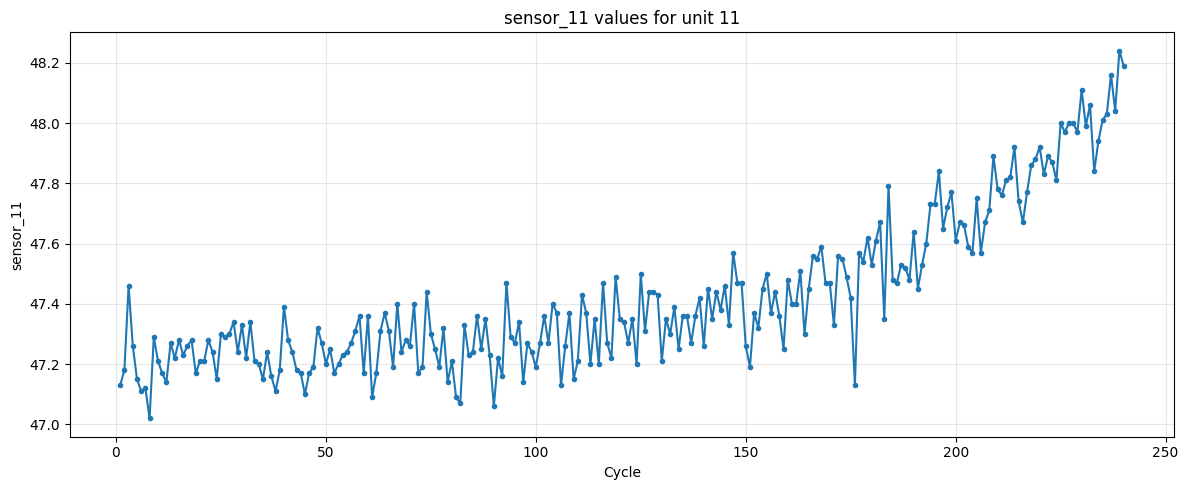

In [6]:
from IPython.display import display

sensor_col = "sensor_11"
unit_id_for_sensor_test = 11

if sensor_col not in train_df.columns:
    raise ValueError(f"Column {sensor_col} was not found")

unit_sensor_df = (
    train_df.loc[
        train_df["unit_id"] == unit_id_for_sensor_test,
        ["unit_id", "cycle", sensor_col, "Remaining Useful Life"],
    ]
    .sort_values("cycle")
    .reset_index(drop=True)
)

if unit_sensor_df.empty:
    raise ValueError(f"No data found for unit_id={unit_id_for_sensor_test}")

print(f"Unit {unit_id_for_sensor_test}, {sensor_col}")
print(f"Rows: {len(unit_sensor_df)}")
print(f"Cycles: {unit_sensor_df['cycle'].min()} - {unit_sensor_df['cycle'].max()}")

display(unit_sensor_df)
display(unit_sensor_df[sensor_col].describe().to_frame(name=sensor_col))

plt.figure(figsize=(12, 5))
plt.plot(
    unit_sensor_df["cycle"],
    unit_sensor_df[sensor_col],
    marker="o",
    linewidth=1.5,
    markersize=3,
)
plt.title(f"{sensor_col} values for unit {unit_id_for_sensor_test}")
plt.xlabel("Cycle")
plt.ylabel(sensor_col)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()